### No spray
- This was used exploration method to combine two parameter such as number of parasitoid and predator to see different result of crop yield.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
noSprayData = pd.read_csv('../../data/pest_hunting/none_natural_enemies.csv')
natural_enemy = noSprayData['number_of_parasitoid'] + noSprayData['number_of_predator']
data = pd.DataFrame({'natural_enemy': natural_enemy, 'yield': noSprayData['finalYield']})

In [3]:
noSprayData = np.array(noSprayData)
numParasite, numPred, yields = noSprayData[:,0], noSprayData[:,1], noSprayData[:,2]

In [5]:
data[0:11]

,natural_enemy,yield
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
5,5,0.0
6,6,0.0
7,7,0.0
8,8,0.0
9,9,0.0


Text(0.5, 0, 'Crop Yield')

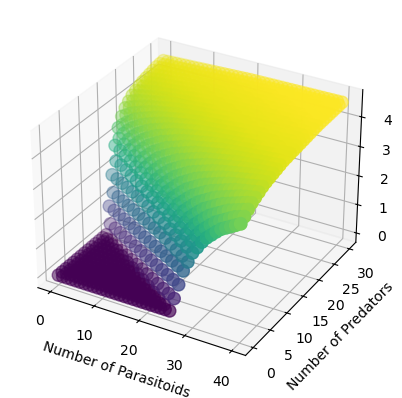

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(numParasite, numPred, yields, c=yields, cmap='viridis', s=80)

ax.set_xlabel("Number of Parasitoids")
ax.set_ylabel("Number of Predators")
ax.set_zlabel("Crop Yield")

### 2D plot

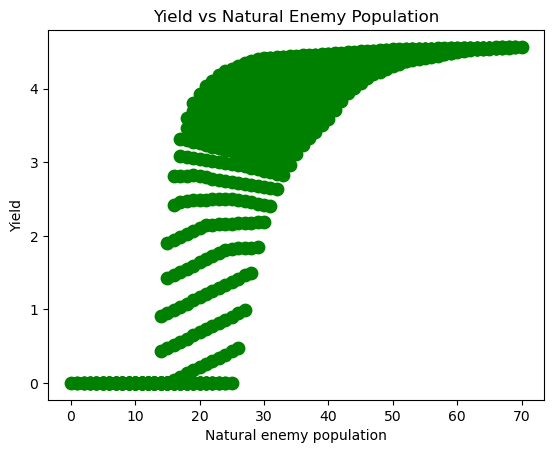

In [12]:
data = np.array(data)
NE, yields = data[:,0], data[:,1]
# fig = plt.figure()
# ax = fig.add_subplot(11, projection='2d')
# ax.scatter(NE, yields, c=yields, cmap='viridis', s=80)

# ax.set_xlabel("Number of natural enemies")
# ax.set_ylabel("Crop Yield")
# # ax.set_zlabel("Crop Yield")

plt.scatter(NE, yields, c="green", s=80)
plt.xlabel("Natural enemy population")
plt.ylabel("Yield")
plt.title("Yield vs Natural Enemy Population")
plt.show()

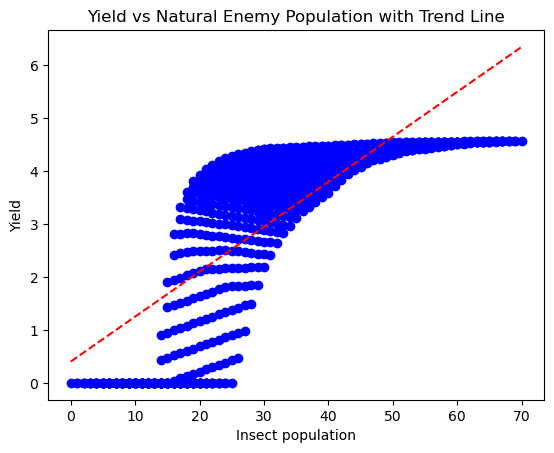

In [13]:
# Trend line
z = np.polyfit(NE, yields, 1)   # linear fit
p = np.poly1d(z)

plt.scatter(NE, yields, c="blue")
plt.plot(NE, p(NE), "r--")
plt.xlabel("Insect population")
plt.ylabel("Yield")
plt.title("Yield vs Natural Enemy Population with Trend Line")
plt.show()

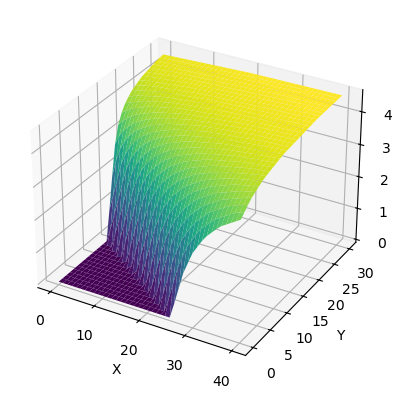

In [21]:
#x, y, z = data[:,0], data[:,1], data[:,2]

# Create grid
X_unique = np.unique(numParasite)
Y_unique = np.unique(numPred)
X, Y = np.meshgrid(X_unique, Y_unique)

# Reshape Z to match grid
Z = np.zeros_like(X, dtype=float)
for i, xv in enumerate(X_unique):
    for j, yv in enumerate(Y_unique):
        mask = (numParasite == xv) & (numPred == yv)
        if np.any(mask):
            Z[j, i] = yields[mask][0]

# Plot 3D surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# plt.contourf(numParasite, numPred, yields, cmap='viridis')
# plt.colorbar(label="Crop Yield")
# plt.xlabel("Number of Parasites")
# plt.ylabel("Number of Predators")
# plt.title("Heatmap of Z depending on X and Y")
# plt.show()